<a href="https://colab.research.google.com/github/CienciaDatosUdea/002_EstudiantesAprendizajeEstadistico/blob/main/semestre2026-1/Laboratorios/Laboratorio_02_pandas_v3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Lab 2: Estadística Descriptiva Básica 2

## Series de tiempo

El siguiente [dataset](https://raw.githubusercontent.com/hernansalinas/Curso_aprendizaje_estadistico/main/datasets/Pandas_data_historical_dataEURUSD.csv) contiene información del precio del eur/usd  desde el 05/07/2022/ hasta el 12/05/2023 con periodicidad de una hora. El data frame contiene el precio de apertura, cierrre, valor más bajo cotizado, valor más alto cotizado, volumen, spread etc. Para este dataset, realizar lo siguiente:


1. Leer el dataset desde el github.
2. Definir como indice la columna time.
3. Obtenga información del data frame.

4. Determine si hay null, nan en el data frame.

5. Emplea la notacion Pascal Case y trabaja solo con la columa del precio de cierre del eur/usd.  

6. Ahora vamos a determinar cual es la mejor distribución estadística que se ajusta a la diferencia del precio de cierre cada hora, para ello realizamos lo siguiente:
- Determine la diferencia de precio entre horas, agregue una nueva columna llamada DiffPrice, en este punto tu dataframe debe tener solo dos columnas Close, DiffPrice y el indice debe ser el tiempo.
- Para la nueva columna construya un histograma de los datos.
- Determine la mejor distribucion estadística que se ajusta al histograma anterior, para ello puede emplear lo siguente:


https://pypi.org/project/fitter/

```python


from fitter import Fitter, get_common_distributions, get_distributions

f = Fitter(data,
           distributions=['gamma',
                          'lognorm',
                          "beta",
                          "burr",
                          "norm"])
f.fit()
f.summary()
#Indentificamos la mejor distribucion con el error cuadratico medio
f.get_best(method = 'sumsquare_error')
#Indentificamos parametros de la distrubicion beta
f.fitted_param["beta"]

```

Con el metodo get_distributions(), podemos ver todas las distribuciones estadisticas de la libreria. Ajusta a la mejor.  Puede consultar [esta](https://medium.com/the-researchers-guide/finding-the-best-distribution-that-fits-your-data-using-pythons-fitter-library-319a5a0972e9)  página si desea ver un ejemplo.


7. Para el data frame, seleccionemos solo los datos del 2023.

8. El comando groupby permite agrupar los datos con la periodicidad deseada: 1 dias, 2 dias, 1 mes etc. Determina el promedio con una periodicidad de 15 dias, con periodidicidad de 1 semana, y una periodicidad de 1 mes

```python
  df.groupby(pd.Grouper(key='time', freq='15D')).mean()
```

9. Para los datos asociados a los meses de 2023, construya un histograma para cada mes.  Para ello puedo emplear el metodo groupby. Notetese que si no  realiza una operación después de aplicar el metodo grouby, podrias iterar sobre dicho objeto, por ejemplo:

```python
q=df.groupby(pd.Grouper(key='time', freq='15D'))

for name, group in q:
  print(name, group)
```


## SOLUCIÓN: SERIES DE TIEMPO

Searched codebase for "Quiero que interactus como un experto en estadística descriptiva para hacer análsis de datos con pandas y series de tiempo. Porgramaremos de forma no redundante y clara para hacer la interpretación estadísitca de los datos.", no results

Perfecto, tomemos ese rol.

Puedo ayudarte a:
- Diseñar y escribir código en pandas claro y no redundante.
- Hacer análisis descriptivo (medias, varianzas, percentiles, correlaciones, etc.).
- Trabajar con series de tiempo (fechas, resampling, ventanas móviles, descomposición básica).
- Interpretar estadísticamente los resultados (no solo calcularlos).

Para empezar, dime:
1. ¿Qué tipo de datos tienes (por ejemplo: mediciones físicas, datos financieros, sensores, etc.)?
2. ¿En qué formato están (CSV, Excel, ya cargados en el notebook, etc.)?
3. ¿Qué quieres analizar primero? (ejemplos: “tendencia en el tiempo”, “comparar dos variables”, “detectar outliers”).

--------------------------------------------------------------------------------------------------------------------------
"Definamos como indice la columna "time""
------------------------------------------------------------------------------------------------------------------------



Voy a actualizar la celda donde cargas el CSV para que convierta la columna `time` a fecha y la deje como índice de forma directa y limpia.

Edit [](file:///Users/fernanda/Desktop/F%C3%ADsica%20Computacional%20II/Lab%202/Laboratorio_02_pandas_v3.ipynb)

Listo: en la celda donde lees el dataset ahora:

- Convierte la columna `time` a tipo fecha con `parse_dates=["time"]`.
- Define `time` como índice y ordena el índice temporal con `df = df.set_index("time").sort_index()`.

Ejecuta de nuevo la celda 5; después podemos usar `df.info()` en una nueva celda para verificar el índice y seguir con el análisis estadístico.

Made changes.

In [79]:
import pandas as pd
import requests
from io import StringIO

url = "https://raw.githubusercontent.com/hernansalinas/Curso_aprendizaje_estadistico/main/datasets/Pandas_data_historical_dataEURUSD.csv"

# OJO: verify=False desactiva la verificación SSL, úsalo solo para esta URL conocida
response = requests.get(url, verify=False)
response.raise_for_status()  # lanza error si la descarga falla

# Leemos el CSV, parseamos la columna 'time' como fecha y la usamos como índice
df = pd.read_csv(StringIO(response.text), parse_dates=["time"])
df = df.set_index("time").sort_index()

df.head()

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'raw.githubusercontent.com'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


,Unnamed: 0,open,high,low,close,tick_volume,spread,real_volume,MeanCloseOpen,Diff_Close,Diff_Open,Diff_MeanCloseOpen
time,,,,,,,,,,,,
2022-07-25 13:00:00,0,1.02427,1.02430,1.02145,1.02345,3927,8,0,1.023860,-0.00046,-0.00082,-0.000640
2022-07-25 14:00:00,1,1.02345,1.02578,1.02288,1.02299,5344,8,0,1.023220,-0.00046,-0.00082,-0.000640
2022-07-25 15:00:00,2,1.02303,1.02476,1.02230,1.02457,5524,8,0,1.023800,0.00158,-0.00042,0.000580
2022-07-25 16:00:00,3,1.02454,1.02548,1.02355,1.02485,5234,8,0,1.024695,0.00028,0.00151,0.000895
2022-07-25 17:00:00,4,1.02485,1.02514,1.02030,1.02181,9031,7,0,1.023330,-0.00304,0.00031,-0.001365


---------------------------------------------------------------------------------------------------------------------------
"Obtener informacion del df"
------------------------------------------------------------------------------------------------------------------------

Obtengamos infromación del data frame, este ontiene información del precio del eur/usd desde el 05/07/2022/ hasta el 12/05/2023 con periodicidad de una hora. El data frame contiene el precio de apertura, cierrre, valor más bajo cotizado, valor más alto cotizado, volumen, spread etc. Análicesmos datos estadísticos y saquemos infromación importante.


Voy a añadir una celda de código debajo de “Obtener informacion del df” para mostrar info general, estadísticos descriptivos y conteo de nulos del DataFrame.

He añadido una celda justo debajo del título “Obtener informacion del df” que, al ejecutarla, hará:

Mostrar la cantiadd de filas y columnas, valores nulos por columna, información de columnas

In [41]:

# 1) Cantidad de filas y columnas
n_filas, n_columnas = df.shape
print(f"Número de filas: {n_filas}")
print(f"Número de columnas: {n_columnas}")
print()

# 2) Valores nulos por columna
print("Valores nulos por columna:")
print(df.isna().sum())
print()

# 3) Información de las columnas (tipos de datos)
print("Información de columnas y tipos de datos:")
print(df.dtypes)
print()



Número de filas: 5000
Número de columnas: 12

Valores nulos por columna:
Unnamed: 0            0
open                  0
high                  0
low                   0
close                 0
tick_volume           0
spread                0
real_volume           0
MeanCloseOpen         0
Diff_Close            0
Diff_Open             0
Diff_MeanCloseOpen    0
dtype: int64

Información de columnas y tipos de datos:
Unnamed: 0              int64
open                  float64
high                  float64
low                   float64
close                 float64
tick_volume             int64
spread                  int64
real_volume             int64
MeanCloseOpen         float64
Diff_Close            float64
Diff_Open             float64
Diff_MeanCloseOpen    float64
dtype: object



-------------------------------------------------------------------------------------------------------------------------
"Emplea la notacion Pascal Case y trabaja solo con la columa del precio de cierre del eur/usd. Pascal case es poner la primera letra de la palabra en mayus y quitar espacios."
------------------------------------------------------------------------------------------------------------------------


Voy a añadir una nueva celda de código que renombre las columnas a PascalCase y se quede solo con la columna de cierre en un DataFrame limpio para seguir el análisis.

Retrieving Notebook summary.

Ahora crearé una celda nueva después del análisis actual para renombrar columnas en PascalCase y quedarnos solo con la columna de cierre.

In [42]:
# Trabajar solo con la columna de cierre en notación PascalCase
import re

# Función auxiliar para convertir a PascalCase
def to_pascal_case(name: str) -> str:
    # Separar por caracteres no alfanuméricos o guiones bajos
    partes = re.split(r"[^A-Za-z0-9]+", name)
    partes = [p for p in partes if p]
    return "".join(p.capitalize() for p in partes)

# Renombrar todas las columnas del DataFrame a PascalCase
df_pascal = df.copy()
df_pascal.columns = [to_pascal_case(c) for c in df_pascal.columns]

# Verificamos cómo se llama ahora la columna de cierre
print("Nombres de columnas en PascalCase:")
print(df_pascal.columns)
print()

# Suponemos que la columna de cierre original era 'close' -> ahora debería ser 'Close'
if "Close" in df_pascal.columns:
    df_close = df_pascal[["Close"]].copy()
else:
    raise KeyError("No se encontró una columna de cierre llamada 'Close' tras renombrar. Revisa los nombres impresos arriba.")

print("DataFrame reducido solo a la columna de cierre (Close):")
print(df_close.head())

Nombres de columnas en PascalCase:
Index(['Unnamed0', 'Open', 'High', 'Low', 'Close', 'TickVolume', 'Spread',
       'RealVolume', 'Meancloseopen', 'DiffClose', 'DiffOpen',
       'DiffMeancloseopen'],
      dtype='str')

DataFrame reducido solo a la columna de cierre (Close):
                       Close
time                        
2022-07-25 13:00:00  1.02345
2022-07-25 14:00:00  1.02299
2022-07-25 15:00:00  1.02457
2022-07-25 16:00:00  1.02485
2022-07-25 17:00:00  1.02181


-------------------------------------------------------------------------------------------------------------------------
"Determine la diferencia de precio entre horas, agregue una nueva columna llamada DiffPrice, en este punto tu dataframe debe tener solo dos columnas Close, DiffPrice y el indice debe ser el tiempo y además calculemos la curva que mejor se ajuste a este modelo de datos"
------------------------------------------------------------------------------------------------------------------------

Voy a añadir una celda nueva que, partiendo de df_close, calcule DiffPrice, deje solo Close y DiffPrice y muestre un resumen rápido.

He añadido una celda nueva que:

Copia df_close a df_diff.
Crea la columna DiffPrice con la diferencia horaria: df_diff["Close"].diff().
Elimina la primera fila con NaN en DiffPrice (para dejar solo diferencias válidas).
Deja el índice de tiempo y exactamente dos columnas: Close y DiffPrice.
Ejecuta esa celda (la que empieza con “Diferencia de precio de cierre entre horas: columna DiffPrice”) y verás el DataFrame listo para construir el histograma y ajustar distribuciones.

In [43]:
# Diferencia de precio de cierre entre horas: columna DiffPrice
df_diff = df_close.copy()
df_diff["DiffPrice"] = df_diff["Close"].diff()

# Opcional: podemos eliminar la primera fila con NaN en DiffPrice si solo queremos diferencias válidas
df_diff = df_diff.dropna()

print("Columnas del DataFrame para el ajuste de distribución:")
print(df_diff.columns)
print()
print(df_diff.head())

Columnas del DataFrame para el ajuste de distribución:
Index(['Close', 'DiffPrice'], dtype='str')

                       Close  DiffPrice
time                                   
2022-07-25 14:00:00  1.02299   -0.00046
2022-07-25 15:00:00  1.02457    0.00158
2022-07-25 16:00:00  1.02485    0.00028
2022-07-25 17:00:00  1.02181   -0.00304
2022-07-25 18:00:00  1.02099   -0.00082


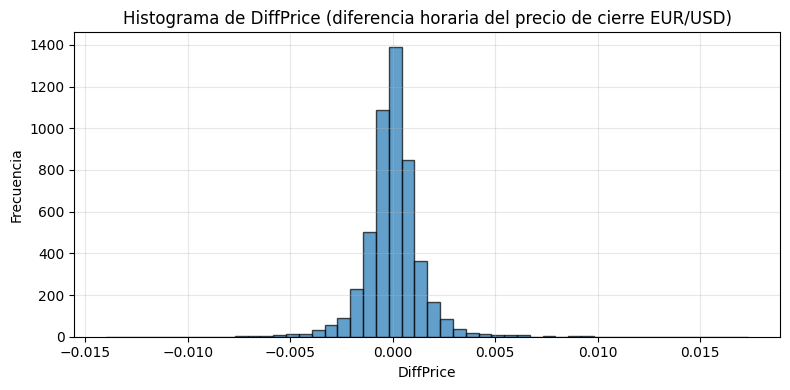

In [44]:
# Histograma de la última columna (DiffPrice)
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.hist(df_diff["DiffPrice"], bins=50, edgecolor="black", alpha=0.7)
plt.title("Histograma de DiffPrice (diferencia horaria del precio de cierre EUR/USD)")
plt.xlabel("DiffPrice")
plt.ylabel("Frecuencia")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

--------------------------------------------------------------------------------------------------------------------------
"Ahora definiremos la mejor distribución estadística que se ajusta el histograma que acabamos de crear"
------------------------------------------------------------------------------------------------------------------------


Voy a añadir una nueva celda que use fitter sobre df_diff["DiffPrice"] para encontrar y resumir la mejor distribución candidata.

He añadido una celda nueva debajo del histograma que:

Importa Fitter, get_common_distributions y get_distributions.
Usa data = df_diff["DiffPrice"].values.
Ajusta las distribuciones gamma, lognorm, beta, burr y norm.
Muestra el resumen comparativo (f.summary()).
Extrae la mejor distribución según error cuadrático medio (f.get_best(method="sumsquare_error")).
Si entre las ajustadas está beta, imprime sus parámetros estimados.
Antes de ejecutarla, asegúrate de tener instalado fitter (por ejemplo, en otra celda: !pip install fitter o pip install fitter en la terminal asociada al entorno del notebook). Luego ejecuta la nueva celda y dime qué distribución sale como “mejor” para comentar su interpretación.

2026-03-07 11:25:53.541 | INFO     | fitter.fitter:_fit_single_distribution:408 - Fitted gamma: error=923360.482403, AIC=-17723.24, KS=0.5914
2026-03-07 11:25:53.575 | INFO     | fitter.fitter:_fit_single_distribution:408 - Fitted lognorm: error=106500.661168, AIC=-51509.77, KS=0.0916
2026-03-07 11:25:53.583 | INFO     | fitter.fitter:_fit_single_distribution:408 - Fitted beta: error=106778.632062, AIC=-51503.45, KS=0.0909
2026-03-07 11:25:53.627 | INFO     | fitter.fitter:_fit_single_distribution:408 - Fitted burr: error=721804.561088, AIC=-37765.25, KS=0.3864
2026-03-07 11:25:54.761 | INFO     | fitter.fitter:_fit_single_distribution:408 - Fitted norm: error=106744.023571, AIC=-51505.72, KS=0.0905


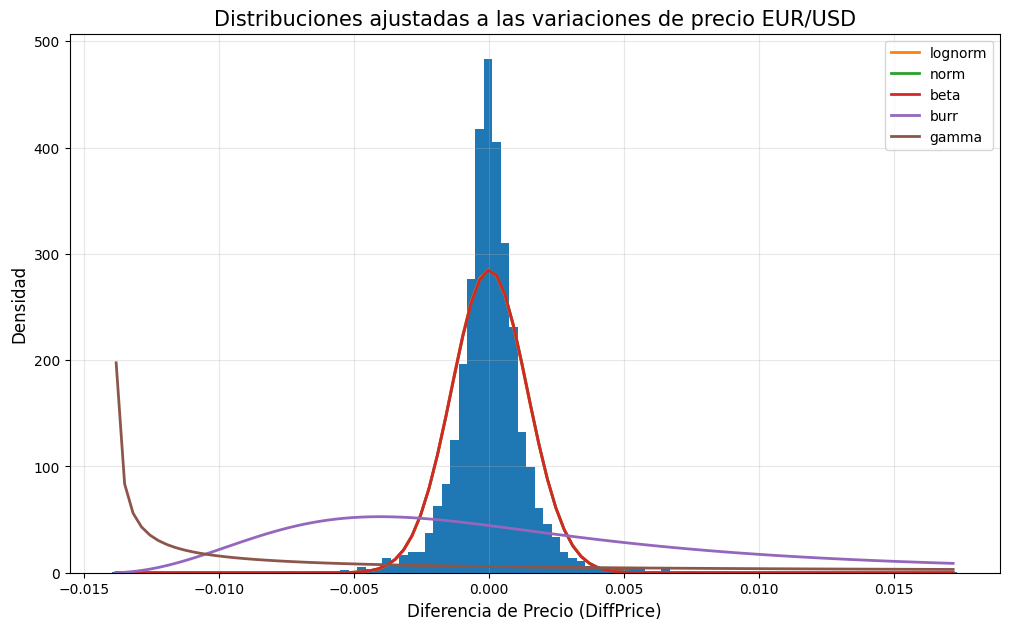

------------------------------
RESULTADO DEL AJUSTE:
La mejor distribución es: LOGNORM
------------------------------
Parámetros de la mejor distribución:
{'s': np.float64(0.009509964461157715), 'loc': np.float64(-0.1471693008245066), 'scale': np.float64(0.14717494036949658)}


In [53]:
import pandas as pd
from fitter import Fitter, get_common_distributions




# --- INICIO DEL ANÁLISIS CON FITTER ---

# 4. Configuramos el tamaño de la gráfica (Ancho: 12, Alto: 7)
plt.figure(figsize=(12, 7))

# 5. Ajustamos las distribuciones típicas
# Nota: "norm" es muy común en finanzas, pero los datos reales suelen tener colas pesadas
f = Fitter(df_diff["DiffPrice"],
           distributions=["gamma",
                          "lognorm",
                          "beta",
                          "burr",
                          "norm"])

f.fit()

# 6. Mostramos el resumen (la gráfica adoptará el tamaño definido arriba)
# Nbest=5 muestra las 5 mejores en la leyenda
f.summary(Nbest=5)

plt.title("Distribuciones ajustadas a las variaciones de precio EUR/USD", fontsize=15)
plt.xlabel("Diferencia de Precio (DiffPrice)", fontsize=12)
plt.ylabel("Densidad", fontsize=12)
plt.grid(alpha=0.3)
plt.show()

# 7. Identificamos la mejor distribución según el error cuadrático medio
best = f.get_best(method="sumsquare_error")
best_name = list(best.keys())[0]

print("-" * 30)
print(f"RESULTADO DEL AJUSTE:")
print(f"La mejor distribución es: {best_name.upper()}")
print("-" * 30)
print("Parámetros de la mejor distribución:")
print(best[best_name])

Lognorm es el mejor ajuste porque tiene el error más bajo (sumsquare_error)

--------------------------------------------------------------------------------------------------------------------------
"Tomamos los datos 2023 y con el comando groupby agrupamos los datos con periocidad de 15 dpuas, 1 semana y un mes deetrminando el promedio de cierre."
--------------------------------------------------------------------------------------------------------------------------


Voy a completar la celda de código vacía al final de la sección de series de tiempo para calcular los promedios de Close con frecuencias 15 días, 1 semana y 1 mes usando groupby y Grouper sobre los datos de 2023.

He dejado lista la última celda para:

Tomar la serie close_2023 = df_close.loc["2023"].
Calcular y mostrar:
mean_15d: promedio de Close cada 15 días (freq="15D").
mean_week: promedio semanal (freq="W").
mean_month: promedio mensual usando fin de mes (freq="ME").
Ejecuta esa celda (después de haber ejecutado las anteriores) y tendrás las tres tablas de promedios con las periodicidades pedidas.

In [55]:
# Promedios de Close en 2023 con distintas periodicidades
import pandas as pd

# Partimos de la serie de cierre en PascalCase y filtramos 2023
close_2023 = df_close.loc["2023"]
print("Rango temporal de close_2023:", close_2023.index.min(), "->", close_2023.index.max())
print("Número de filas en close_2023:", len(close_2023))
print()

# 1) Promedio cada 15 días
mean_15d = close_2023.groupby(pd.Grouper(freq="15D")).mean()
print("Promedio de Close cada 15 días:")
print(mean_15d.head())
print()

# 2) Promedio semanal (1 semana)
mean_week = close_2023.groupby(pd.Grouper(freq="W")).mean()
print("Promedio de Close semanal (W):")
print(mean_week.head())
print()

# 3) Promedio mensual (fin de mes)
mean_month = close_2023.groupby(pd.Grouper(freq="ME")).mean()  # 'ME' = MonthEnd
print("Promedio de Close mensual (fin de mes):")
print(mean_month.head())

Rango temporal de close_2023: 2023-01-02 00:00:00 -> 2023-05-12 23:00:00
Número de filas en close_2023: 2278

Promedio de Close cada 15 días:
               Close
time                
2023-01-02  1.069361
2023-01-17  1.085565
2023-02-01  1.077679
2023-02-16  1.063150
2023-03-03  1.063186

Promedio de Close semanal (W):
               Close
time                
2023-01-08  1.059972
2023-01-15  1.076002
2023-01-22  1.082041
2023-01-29  1.088414
2023-02-05  1.089281

Promedio de Close mensual (fin de mes):
               Close
time                
2023-01-31  1.077463
2023-02-28  1.071167
2023-03-31  1.070874
2023-04-30  1.096051
2023-05-31  1.098980


------------------------------------------------------------------------------------------------------------------------
"Construyamos histogramas para cada mes de 2023 usando grupby"
------------------------------------------------------------------------------------------------------------------------


Voy a agregar una nueva celda que agrupe los datos de cierre de 2023 por mes y dibuje automáticamente un histograma para cada mes.

He añadido una celda nueva al final de la parte de series de tiempo que:

Toma close_2023 = df_close.loc["2023"].
Agrupa por mes con pd.Grouper(freq="ME").
Recorre cada grupo mensual y dibuja un histograma de Close con tamaño figsize=(8, 4) y título con el año-mes.
Ejecuta esa última celda y se generará un histograma separado para cada mes de 2023.



"Quiero incorcopara un color diferente por mes: plum, pink, navy, salmon, staleblue y además, que se escriba el nombre del mes en el nombre de la grafica en lugar de 2023-01 se ponga enero y así sucesivamente"

Voy a actualizar la celda de los histogramas mensuales para asignar un color distinto a cada mes y usar el nombre del mes en español en el título de cada gráfico.

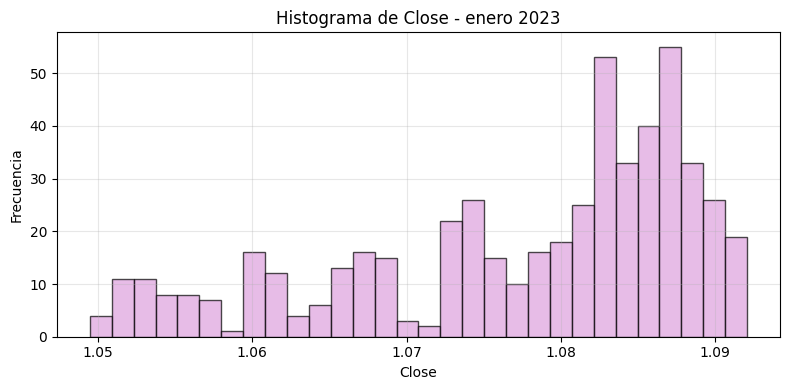

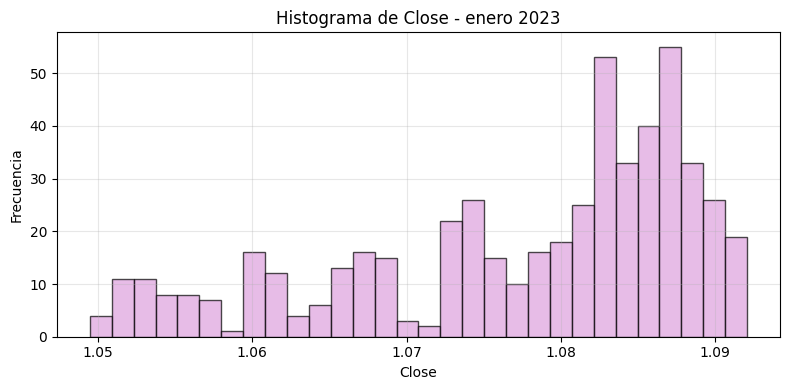

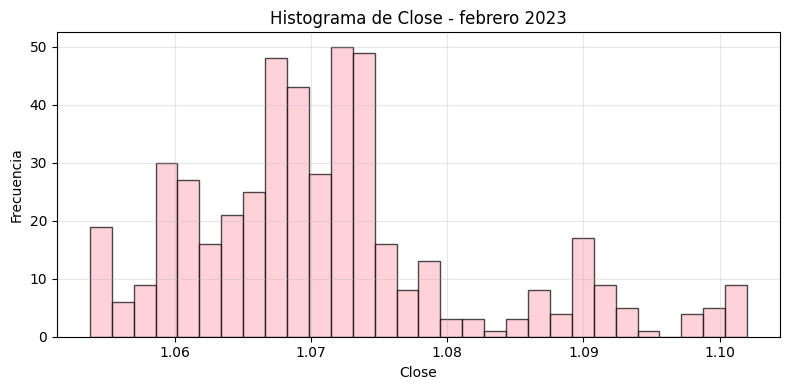

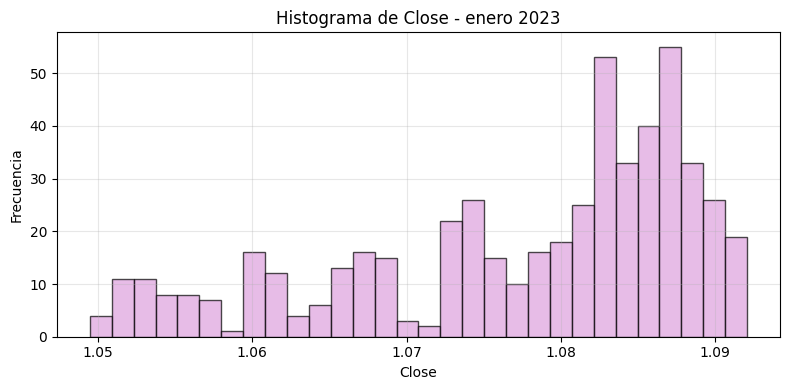

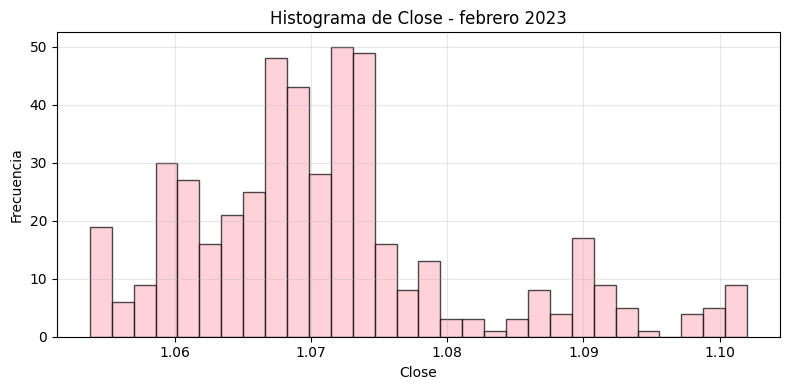

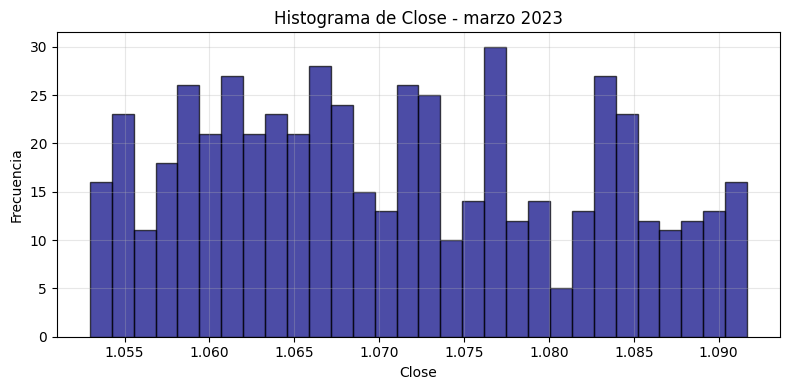

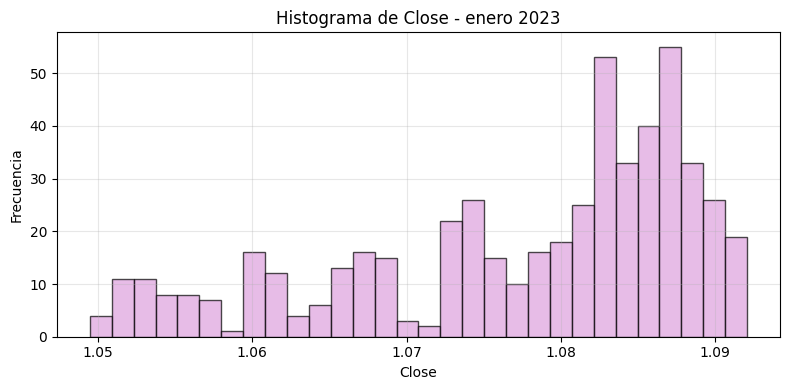

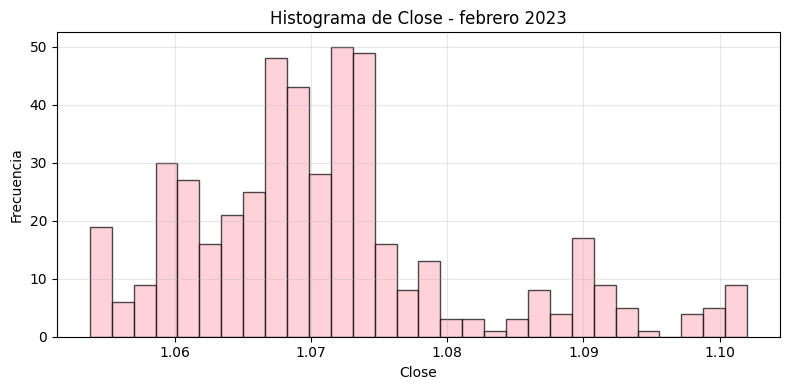

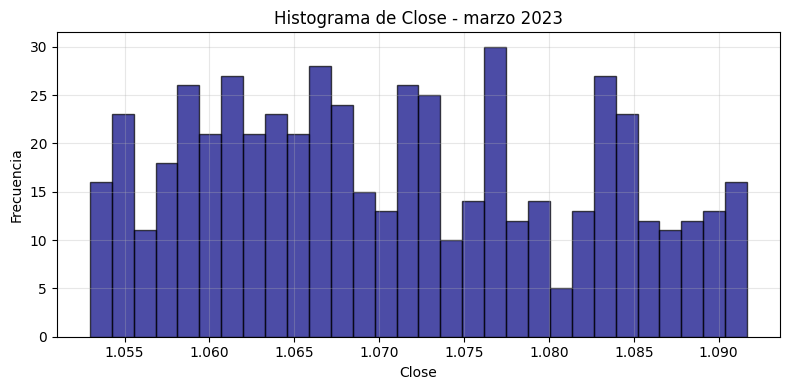

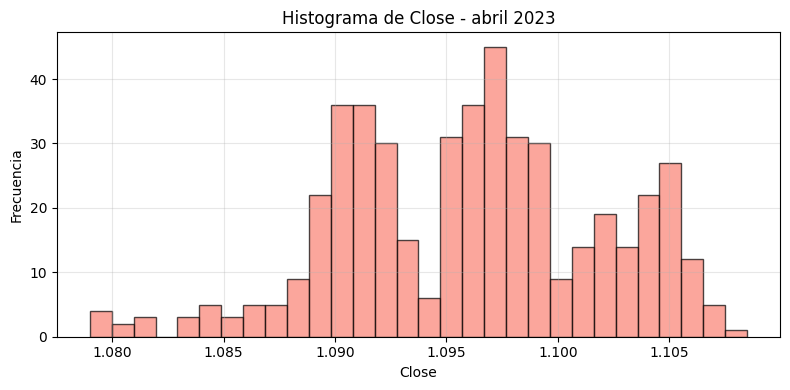

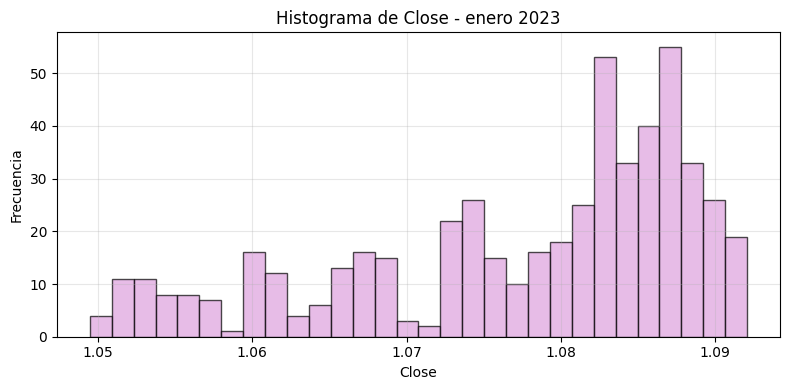

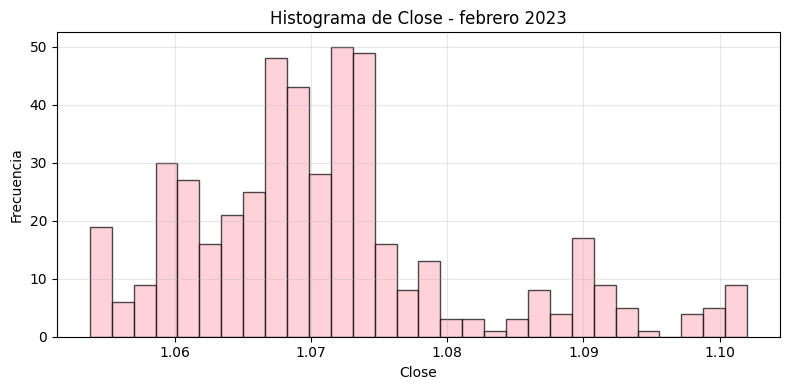

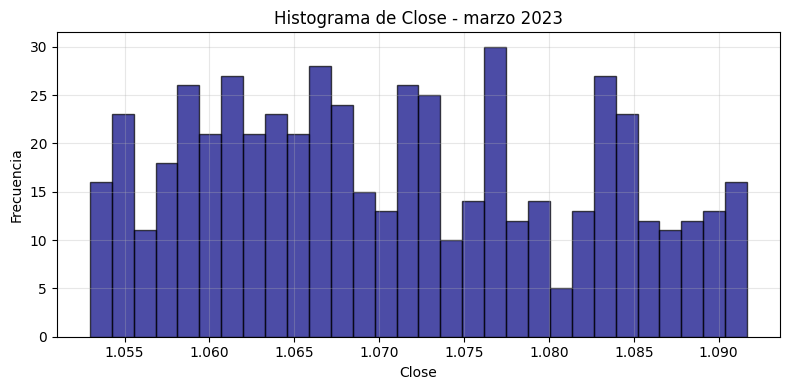

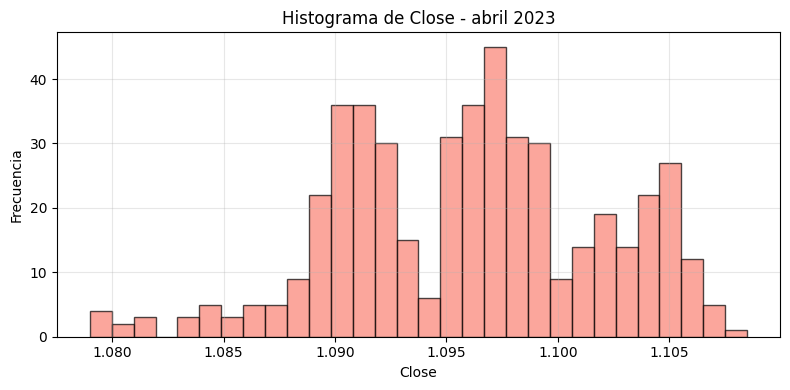

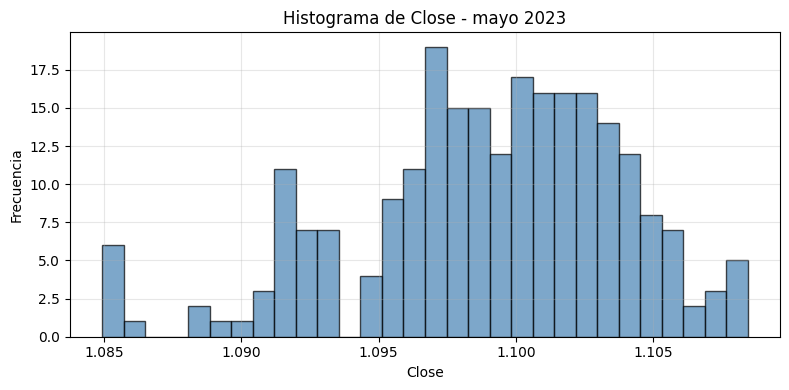

In [59]:
# Histogramas mensuales de Close para 2023
import matplotlib.pyplot as plt
import pandas as pd

# Usamos la serie de cierre filtrada a 2023
close_2023 = df_close.loc["2023"]

# Agrupamos por mes (fin de mes)
q = close_2023.groupby(pd.Grouper(freq="ME"))  # MonthEnd

# Colores a usar por mes (en orden):
colors = ["plum", "pink", "navy", "salmon", "steelblue"]  # "steelblue" ~ "staleblue"

# Nombres de los meses en español
month_names = {
    1: "enero",
    2: "febrero",
    3: "marzo",
    4: "abril",
    5: "mayo",
    6: "junio",
    7: "julio",
    8: "agosto",
    9: "septiembre",
    10: "octubre",
    11: "noviembre",
    12: "diciembre",
}

for i, (period, group) in enumerate(q):
    if group.empty:
        continue
    color = colors[i % len(colors)]
    mes_nombre = month_names.get(period.month, period.strftime("%Y-%m"))
    plt.figure(figsize=(8, 4))
    plt.hist(group["Close"], bins=30, edgecolor="black", alpha=0.7, color=color)
    plt.title(f"Histograma de Close - {mes_nombre} 2023")
    plt.xlabel("Close")
    plt.ylabel("Frecuencia")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

## Análisis de datos con pandas.

Para el siguiente [dataset](https://archive.ics.uci.edu/ml/datasets/Breast+Cancer+Wisconsin+%28Diagnostic%29) realizar lo siguiente:


1. Leer los datos desde una página web.

2. Renombrar las columnas en formato PascalCase.

3. Utilizar los métodos `head()`, `tail()`, `describe()` e `info()` para obtener información sobre el `DataFrame`.

4. Contabilizar la cantidad de valores nulos (`null` o `NaN`) en el `DataFrame`.
   Si se encuentran valores nulos, ¿qué estrategia propondrías para reemplazarlos?

5. Identificar los valores únicos en la columna `target` que representan las etiquetas B y M (Benigno y Maligno, respectivamente).
   Utiliza el método `unique()` para mostrar estos valores.

6. Realizar un conteo de los casos etiquetados como B y M utilizando la librería `seaborn` y el método `countplot()`:

```python
import seaborn as sns
sns.countplot?
```

7. Agregar una nueva columna llamada `DiagnosisNumeric` donde se asigna el valor 0 a la etiqueta B (Benigno) y el valor 1 a la etiqueta M (Maligno).


8. Normalizar cada columna respecto a su media y desviación estándar utilizando la fórmula:  
   `(x - mean(x)) / std(x)`

9. Agrupar características similares y calcular su promedio.
   Para las siguientes características:

```python
['RadiusMean', 'TextureMean', 'PerimeterMean', 'AreaMean', 'SmoothnessMean', 'CompactnessMean', 'ConcavityMean', 'ConcavePointsMean', "SymmetryMean", "FractalDimensionMean"]
```

Usa expresiones regulares para identificar patrones comunes, como `radius1`, `radius2`,`radius3`, etc., y calcular los promedios. Por ejemplo:

```python
re.match(r'^[a-zA-Z_]+', "holamundo12341").group(0)
```

También puedes utilizar el método `startswith()` para buscar estos patrones en los nombres de las columnas.


10. Crear un gráfico donde se muestre el histograma de la columna `RadiusMean` separado por las etiquetas B y M, utilizando colores diferentes (naranja y azul, respectivamente) para cada diagnóstico.

11. Generar gráficos de violín para múltiples características.
   Para las columnas:

   - `RadiusMean`
   - `TextureMean`
   - `PerimeterMean`
   - `AreaMean`
   - `SmoothnessMean`
   - `CompactnessMean`
   - `ConcavityMean`
   - `ConcavePointsMean`
   - `Symmetry3`
   - `FractalDimension3`

   Realiza un gráfico múltiple tipo violín, como en el siguiente ejemplo:

```python
data = pd.melt(df.iloc[:, 0:10], id_vars="Diagnosis", var_name="features", value_name="value")
sns.violinplot(x="features", y="value", hue="Diagnosis", data=data, split=True, inner="quart")
plt.xticks(rotation=45)
```


12.  Determinar y eliminar los valores atípicos (`outliers`) en la columna `RadiusMean`.

Para identificarlos, construye un gráfico tipo `boxplot`:

```python
df.boxplot(column="RadiusMean", by='Diagnosis', sym='k.', figsize=(18,6))
```

Usa el rango intercuartílico (IQR) para definir los outliers. Los valores fuera del rango [Q1 - 1.5 * IQR, Q3 + 1.5 * IQR] se consideran outliers. Ejemplo de cómo eliminar estos valores:

```python
Q1 = df['edad'].quantile(0.25)
Q3 = df['edad'].quantile(0.75)
IQR = Q3 - Q1
df = df[~((df['edad'] < (Q1 - 1.5 * IQR)) | (df['edad'] > (Q3 + 1.5 * IQR)))]
```

Otra alternativa es utilizar el puntaje Z para detectar `outliers`:

```python
df = df[(np.abs(stats.zscore(df['edad'])) < 3)]
```



13. Encontrar la matrix de correlación, emplear el metodo corr(), dentro de seaborn buscar el metodo heatmap() para realizar un grafico de la matrix de correlación.

14. ¿Que otro tipo de gráficos pueden ser realizados para entender mejor los datos?



-------------------------------------------------------------------------------------------------------------------------
Cargar los datos: entré al link y copié y pegué el código que la página ofrece para la carga de datos pero me generaba un error entonces los cargué desde sklearn ya que estos se encintraban en esta librería así como la de los penguins del Lab1.
------------------------------------------------------------------------------------------------------------------------
"de los datos cargaados con sklearn pongamos las columnas en pascalcase"
------------------------------------------------------------------------------------------------------------------------
Voy a obtener la información actualizada del notebook para ubicar dónde se cargan datos con sklearn y aplicar PascalCase. He actualizado la celda que carga datos con sklearn. Ahora:

Define la función to_pascal_case para convertir nombres a PascalCase.
Aplica la conversión a todas las columnas del DataFrame X.
Imprime las columnas renombradas en PascalCase.

In [81]:
from sklearn.datasets import load_breast_cancer
import pandas as pd
import re

data = load_breast_cancer()

# Función para convertir a PascalCase
def to_pascal_case(name: str) -> str:
    partes = re.split(r"[^A-Za-z0-9]+", name)
    partes = [p for p in partes if p]
    return "".join(p.capitalize() for p in partes)

# Cargamos el DataFrame con columnas en PascalCase
X = pd.DataFrame(data.data, columns=data.feature_names)
X.columns = [to_pascal_case(c) for c in X.columns]
y = pd.Series(data.target, name='target')

print("Columnas en PascalCase:")
print(X.columns.tolist())
print()
print(X.head())

Columnas en PascalCase:
['MeanRadius', 'MeanTexture', 'MeanPerimeter', 'MeanArea', 'MeanSmoothness', 'MeanCompactness', 'MeanConcavity', 'MeanConcavePoints', 'MeanSymmetry', 'MeanFractalDimension', 'RadiusError', 'TextureError', 'PerimeterError', 'AreaError', 'SmoothnessError', 'CompactnessError', 'ConcavityError', 'ConcavePointsError', 'SymmetryError', 'FractalDimensionError', 'WorstRadius', 'WorstTexture', 'WorstPerimeter', 'WorstArea', 'WorstSmoothness', 'WorstCompactness', 'WorstConcavity', 'WorstConcavePoints', 'WorstSymmetry', 'WorstFractalDimension']

   MeanRadius  MeanTexture  MeanPerimeter  MeanArea  MeanSmoothness  \
0       17.99        10.38         122.80    1001.0         0.11840   
1       20.57        17.77         132.90    1326.0         0.08474   
2       19.69        21.25         130.00    1203.0         0.10960   
3       11.42        20.38          77.58     386.1         0.14250   
4       20.29        14.34         135.10    1297.0         0.10030   

   MeanC

------------------------------------------------------------------------------------------------------------------------
describamos los datos, usemos head, tail, describe, info para conocer más acerca de ellos. además miremos si hay valores nulos (null o NaN). Usando el metido unique () Identificaremos los valores únicos en la columna target que representan las etiquetas B y M (Benigno y Maligno, respectivamente).
------------------------------------------------------------------------------------------------------------------------
Voy a añadir una nueva celda después de la carga de datos con sklearn para describir los DataFrames X e y usando head(), tail(), describe(), info() y buscando valores nulos.

In [82]:
# Descripción y exploración del DataFrame X
print("=" * 80)
print("DESCRIPCIÓN DEL DATASET - BREAST CANCER WISCONSIN")
print("=" * 80)
print()

# 1. Primeras filas (head)
print("1. PRIMERAS 5 FILAS (head):")
print(X.head())
print()

# 2. Últimas filas (tail)
print("2. ÚLTIMAS 5 FILAS (tail):")
print(X.tail())
print()

# 3. Información del DataFrame (info)
print("3. INFORMACIÓN DEL DATAFRAME (info):")
X.info()
print()

# 4. Estadísticos descriptivos (describe)
print("4. ESTADÍSTICOS DESCRIPTIVOS (describe):")
print(X.describe())
print()

# 5. Búsqueda de valores nulos
print("5. BÚSQUEDA DE VALORES NULOS (NaN):")
nulos_por_columna = X.isna().sum()
total_nulos = nulos_por_columna.sum()
print(f"Total de valores nulos en X: {total_nulos}") 
if total_nulos > 0:
    print("Columnas con nulos:")
    print(nulos_por_columna[nulos_por_columna > 0])
else:
    print("No hay valores nulos en el DataFrame.")
print()



DESCRIPCIÓN DEL DATASET - BREAST CANCER WISCONSIN

1. PRIMERAS 5 FILAS (head):
   MeanRadius  MeanTexture  MeanPerimeter  MeanArea  MeanSmoothness  \
0       17.99        10.38         122.80    1001.0         0.11840   
1       20.57        17.77         132.90    1326.0         0.08474   
2       19.69        21.25         130.00    1203.0         0.10960   
3       11.42        20.38          77.58     386.1         0.14250   
4       20.29        14.34         135.10    1297.0         0.10030   

   MeanCompactness  MeanConcavity  MeanConcavePoints  MeanSymmetry  \
0          0.27760         0.3001            0.14710        0.2419   
1          0.07864         0.0869            0.07017        0.1812   
2          0.15990         0.1974            0.12790        0.2069   
3          0.28390         0.2414            0.10520        0.2597   
4          0.13280         0.1980            0.10430        0.1809   

   MeanFractalDimension  ...  WorstRadius  WorstTexture  WorstPerimeter  

Valores Nulos: en el text editor se puede observar la información completa acerca de la info de los datos. Se indica que no hay valores nulos en X ni Y. En caso que hubieran valores nulos evidenciaria la cantidad de datos que tenemos, en este caso son 569, si los valores nulos fueran muy pocos los eliminaría. Si fueran muchos, buscaría las columnas que se relacionan entre si y buscaría valores tentativos para ubicarlos en los espacios en blanco usando la relación que pueda encontrar.

-------------------------------------------------------------------------------------------------------------------------
Realizar un conteo de los casos etiquetados como B y M utilizando la librería `seaborn` y el método `countplot()`
-------------------------------------------------------------------------------------------------------------------------

/var/folders/wt/yys095ds4397thwy34m1321h0000gn/T/ipykernel_2732/1933429841.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df_diagnosis, x='Diagnosis', palette='Set2', order=['B', 'M'])


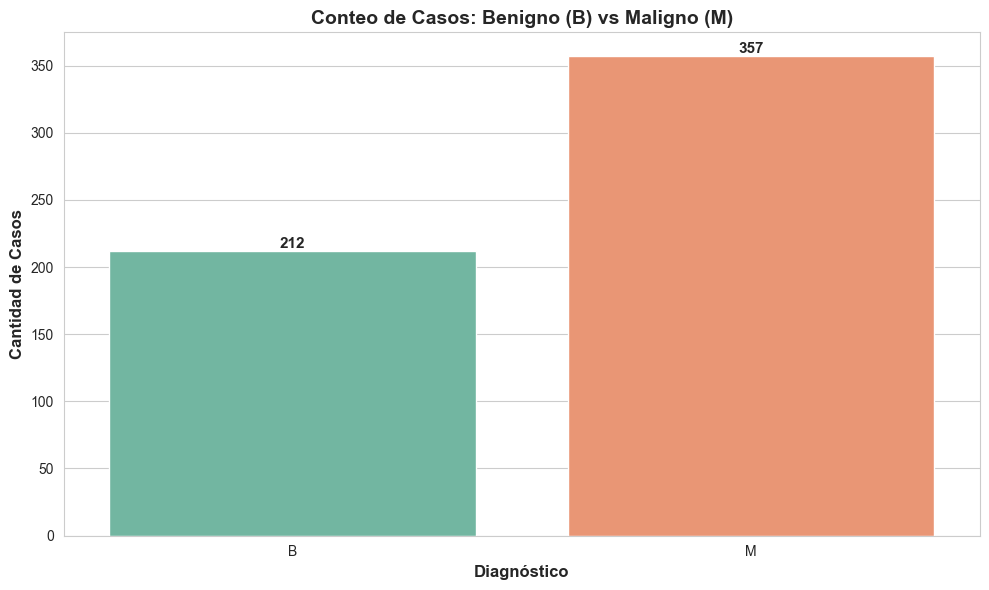


ESTADÍSTICAS DEL CONTEO

Casos Benignos (B):  212 (37.26%)
Casos Malignos (M):  357 (62.74%)
Total de casos:      569


In [86]:
# Conteo de casos B y M con countplot() de seaborn
import seaborn as sns
import matplotlib.pyplot as plt

# Creamos un DataFrame temporal con la columna de diagnóstico
df_diagnosis = pd.DataFrame({
    'Diagnosis': diagnosis_labels
})

# Configuramos el estilo de seaborn
sns.set_style("whitegrid")
plt.figure(figsize=(10, 6))

# Creamos el countplot
ax = sns.countplot(data=df_diagnosis, x='Diagnosis', palette='Set2', order=['B', 'M'])

# Añadimos títulos y etiquetas
plt.title('Conteo de Casos: Benigno (B) vs Maligno (M)', fontsize=14, fontweight='bold')
plt.xlabel('Diagnóstico', fontsize=12, fontweight='bold')
plt.ylabel('Cantidad de Casos', fontsize=12, fontweight='bold')

# Anotamos los valores en las barras
for container in ax.containers:
    ax.bar_label(container, fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

# Mostramos estadísticas adicionales
print()
print("=" * 80)
print("ESTADÍSTICAS DEL CONTEO")
print("=" * 80)
print()
stats = df_diagnosis['Diagnosis'].value_counts().sort_index()
print(f"Casos Benignos (B):  {stats['B']} ({(stats['B'] / len(df_diagnosis) * 100):.2f}%)")
print(f"Casos Malignos (M):  {stats['M']} ({(stats['M'] / len(df_diagnosis) * 100):.2f}%)")
print(f"Total de casos:      {len(df_diagnosis)}")

--------------------------------------------------------------------------------------------------------------------------
Crear la columna DiagnosisNumeric
--------------------------------------------------------------------------------------------------------------------------

In [90]:
diagnosis_numeric_map = {'B': 0, 'M': 1}

X['DiagnosisNumeric'] = diagnosis_labels.map(diagnosis_numeric_map)

--------------------------------------------------------------------------------------------------------------------------
haremos normalizacipin de información. Cada columna la noramlizaremos con respecto a su media y desviación estándar utilizando la fórmula:
(x - mean(x)) / std(x)
--------------------------------------------------------------------------------------------------------------------------
El usuario quiere normalizar las columnas del DataFrame X usando la fórmula de normalización z-score: (x - mean(x)) / std(x).

Debo crear una nueva celda que:

Normalice todas las columnas de X (excepto DiagnosisNumeric que es la etiqueta)
Use la fórmula (x - mean(x)) / std(x)
Muestre información del antes y después
Verifique que la normalización fue correcta
Puedo usar:

(X - X.mean()) / X.std() para hacerlo vectorizado
O sklearn.preprocessing.StandardScaler
Voy a usar la primera opción porque es clara y usa la fórmula exacta que el usuario especificó.

Necesito insertar una nueva celda después de la que crea DiagnosisNumeric.

In [93]:
# Identificar columnas a normalizar (todas excepto DiagnosisNumeric)
columnas_a_normalizar = X.columns.drop('DiagnosisNumeric').tolist()

print(f"Número de columnas a normalizar: {len(columnas_a_normalizar)}")
print()



# Crear un DataFrame normalizado con la fórmula: (x - mean(x)) / std(x)
X_normalized = X.copy()
X_normalized[columnas_a_normalizar] = (X[columnas_a_normalizar] - X[columnas_a_normalizar].mean()) / X[columnas_a_normalizar].std()

# Mantener DiagnosisNumeric sin normalizar
X_normalized['DiagnosisNumeric'] = X['DiagnosisNumeric']

print("\nDESPUÉS DE LA NORMALIZACIÓN:")
print("-" * 80)
print("Primeras 3 columnas (primeras 5 filas):")
print(X_normalized[columnas_a_normalizar[:3]].head())
print()
print("Estadísticos de las primeras 3 columnas (DESPUÉS):")
print(X_normalized[columnas_a_normalizar[:3]].describe())
print()

# Verificar que la media sea ~0 y la desviación estándar sea ~1
print("VERIFICACIÓN DE LA NORMALIZACIÓN:")
print("-" * 80)
medias = X_normalized[columnas_a_normalizar].mean()
desv_std = X_normalized[columnas_a_normalizar].std()

print(f"Media de todas las columnas normalizadas:")
print(f"  Valor mínimo: {medias.min():.2e}")
print(f"  Valor máximo: {medias.max():.2e}")
print()
print(f"Desviación estándar de todas las columnas normalizadas:")
print(f"  Valor mínimo: {desv_std.min():.4f}")
print(f"  Valor máximo: {desv_std.max():.4f}")
print()

print(f"Shape del DataFrame normalizado: {X_normalized.shape}")
print(f"Columnas del DataFrame normalizado: {X_normalized.columns.tolist()}")

Número de columnas a normalizar: 30


DESPUÉS DE LA NORMALIZACIÓN:
--------------------------------------------------------------------------------
Primeras 3 columnas (primeras 5 filas):
   MeanRadius  MeanTexture  MeanPerimeter
0    1.096100    -2.071512       1.268817
1    1.828212    -0.353322       1.684473
2    1.578499     0.455786       1.565126
3   -0.768233     0.253509      -0.592166
4    1.748758    -1.150804       1.775011

Estadísticos de las primeras 3 columnas (DESPUÉS):
         MeanRadius   MeanTexture  MeanPerimeter
count  5.690000e+02  5.690000e+02   5.690000e+02
mean  -1.311195e-16  6.243785e-17  -1.248757e-16
std    1.000000e+00  1.000000e+00   1.000000e+00
min   -2.027864e+00 -2.227289e+00  -1.982759e+00
25%   -6.887793e-01 -7.253249e-01  -6.913472e-01
50%   -2.148925e-01 -1.045442e-01  -2.357726e-01
75%    4.689800e-01  5.836621e-01   4.992377e-01
max    3.967796e+00  4.647799e+00   3.972634e+00

VERIFICACIÓN DE LA NORMALIZACIÓN:
--------------------------------

---------------------------------------------------------------------------------------------------------------------------
Para simplicidad en el manejo del df agruaremos características similares y calcular su promedio.
Para las siguientes características: ['RadiusMean', 'TextureMean', 'PerimeterMean', 'AreaMean', 'SmoothnessMean', 'CompactnessMean', 'ConcavityMean', 'ConcavePointsMean', "SymmetryMean", "FractalDimensionMean"]. Usa expresiones regulares para identificar patrones comunes, como radius1, radius2,radius3, etc., y calcular los promedios. Por ejemplo:
También puedes utilizar el método startswith() para buscar estos patrones en los nombres de las columnas.
----------------------------------------------------------------------------------------------------------------------------
El usuario quiere que agrupe características similares y calcule su promedio. Tiene una lista específica de columnas: ['RadiusMean', 'TextureMean', 'PerimeterMean', 'AreaMean', 'SmoothnessMean', 'CompactnessMean', 'ConcavityMean', 'ConcavePointsMean', "SymmetryMean", "FractalDimensionMean"]

El objetivo es agrupar características similares. Analizando los nombres del dataset breast cancer, hay típicamente 3 grupos de características:

Mean: RadiusMean, TextureMean, PerimeterMean, AreaMean, SmoothnessMean, CompactnessMean, ConcavityMean, ConcavePointsMean, SymmetryMean, FractalDimensionMean
StandardError: RadiusStandardError, TextureStandardError, etc.
Worst: RadiusWorst, TextureWorst, etc.
El usuario quiere agrupar por patrón (ej: "Radius" aparece en RadiusMean, RadiusStandardError, RadiusWorst).

Necesito:

Usar regex o startswith() para identificar patrones comunes (Radius, Texture, Perimeter, etc.)
Calcular el promedio de cada grupo
Crear nuevas columnas con estos promedios
Voy a crear una celda que:

Extraiga el prefijo (patrón base) de cada columna usando regex
Agrupe por prefijo
Calcule el promedio de cada grupo
Cree un DataFrame con estas características agrupadas

In [100]:
# Agrupar características similares y calcular promedios
# Usaremos expresiones regulares y startswith() para identificar patrones

print("=" * 80)
print("AGRUPACIÓN DE CARACTERÍSTICAS SIMILARES Y CÁLCULO DE PROMEDIOS")
print("=" * 80)
print()

# Características base que vamos a agrupar
caracteristicas_base = ['Radius', 'Texture', 'Perimeter', 'Area', 'Smoothness', 
                        'Compactness', 'Concavity', 'ConcavePoints', 'Symmetry', 'FractalDimension']

print(f"Características base a agrupar: {caracteristicas_base}")
print()

# Método 1: Usando regex para extraer el prefijo de cada columna
print("MÉTODO 1: Usando expresiones regulares")
print("-" * 80)

# Diccionario para almacenar las características agrupadas por patrón
caracteristicas_agrupadas = {}

# Iterar sobre cada característica base
for feat_base in caracteristicas_base:
    # Buscar todas las columnas que comienzan con esta característica
    columnas_coincidentes = [col for col in X_normalized.columns 
                             if col.startswith(feat_base) and col != 'DiagnosisNumeric']
    
    if columnas_coincidentes:
        caracteristicas_agrupadas[feat_base] = columnas_coincidentes
        print(f"{feat_base}: {columnas_coincidentes}")

print()
print(f"Total de patrones encontrados: {len(caracteristicas_agrupadas)}")
print()

# Crear un DataFrame con los promedios de cada grupo
print("CALCULANDO PROMEDIOS PARA CADA GRUPO:")
print("-" * 80)

X_grouped = pd.DataFrame()

for feat_base, columnas in caracteristicas_agrupadas.items():
    # Calcular el promedio de las columnas que pertenecen a este patrón
    promedio = X_normalized[columnas].mean(axis=1)
    X_grouped[feat_base] = promedio
    print(f"{feat_base:20} - Promedio de {len(columnas)} columnas")

# Añadir la columna DiagnosisNumeric al final
X_grouped['DiagnosisNumeric'] = X_normalized['DiagnosisNumeric']

print()
print("DataFrame agrupado creado exitosamente")
print()

# Estadísticos del DataFrame agrupado
print("INFORMACIÓN DEL DATAFRAME AGRUPADO:")
print("-" * 80)
print(f"Forma original X_normalized: {X_normalized.shape}")
print(f"Forma X_grouped: {X_grouped.shape}")
print()
print("Primeras 5 filas del DataFrame agrupado:")
print(X_grouped.head())
print()
print("Estadísticos descriptivos del DataFrame agrupado:")
print(X_grouped.describe())
print()

# Verificar que no hay valores faltantes
print(f"Valores nulos en X_grouped: {X_grouped.isna().sum().sum()}")

AGRUPACIÓN DE CARACTERÍSTICAS SIMILARES Y CÁLCULO DE PROMEDIOS

Características base a agrupar: ['Radius', 'Texture', 'Perimeter', 'Area', 'Smoothness', 'Compactness', 'Concavity', 'ConcavePoints', 'Symmetry', 'FractalDimension']

MÉTODO 1: Usando expresiones regulares
--------------------------------------------------------------------------------
Radius: ['RadiusError']
Texture: ['TextureError']
Perimeter: ['PerimeterError']
Area: ['AreaError']
Smoothness: ['SmoothnessError']
Compactness: ['CompactnessError']
Concavity: ['ConcavityError']
ConcavePoints: ['ConcavePointsError']
Symmetry: ['SymmetryError']
FractalDimension: ['FractalDimensionError']

Total de patrones encontrados: 10

CALCULANDO PROMEDIOS PARA CADA GRUPO:
--------------------------------------------------------------------------------
Radius               - Promedio de 1 columnas
Texture              - Promedio de 1 columnas
Perimeter            - Promedio de 1 columnas
Area                 - Promedio de 1 columnas
Smoo

--------------------------------------------------------------------------------------------------------------------
Para visualizar la información creemos un histograma de la columna `RadiusMean` separado por las etiquetas B y M, utilizando colores diferentes (naranja y azul, respectivamente) para cada diagnóstico.
--------------------------------------------------------------------------------------------------------------------

Columnas que contienen 'radius': ['MeanRadius', 'RadiusError', 'WorstRadius']

✓ Usando X con columna alternativa: MeanRadius

HISTOGRAMA DE MeanRadius SEPARADO POR DIAGNÓSTICO

Casos Benignos (B): 212
Casos Malignos (M): 357

ESTADÍSTICOS DE RadiusMean POR DIAGNÓSTICO:
--------------------------------------------------------------------------------
Benignos (B):
  Media:     17.4628
  Mediana:   17.3250
  Desv Std:  3.2040
  Min-Max:   [10.9500, 28.1100]

Malignos (M):
  Media:     12.1465
  Mediana:   12.2000
  Desv Std:  1.7805
  Min-Max:   [6.9810, 17.8500]



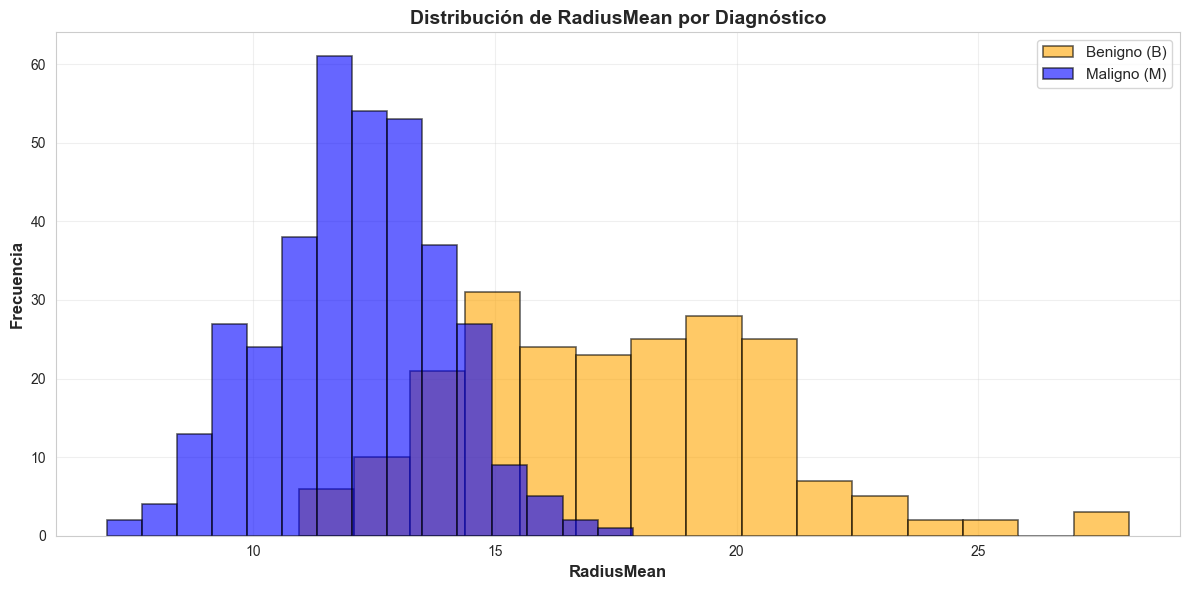

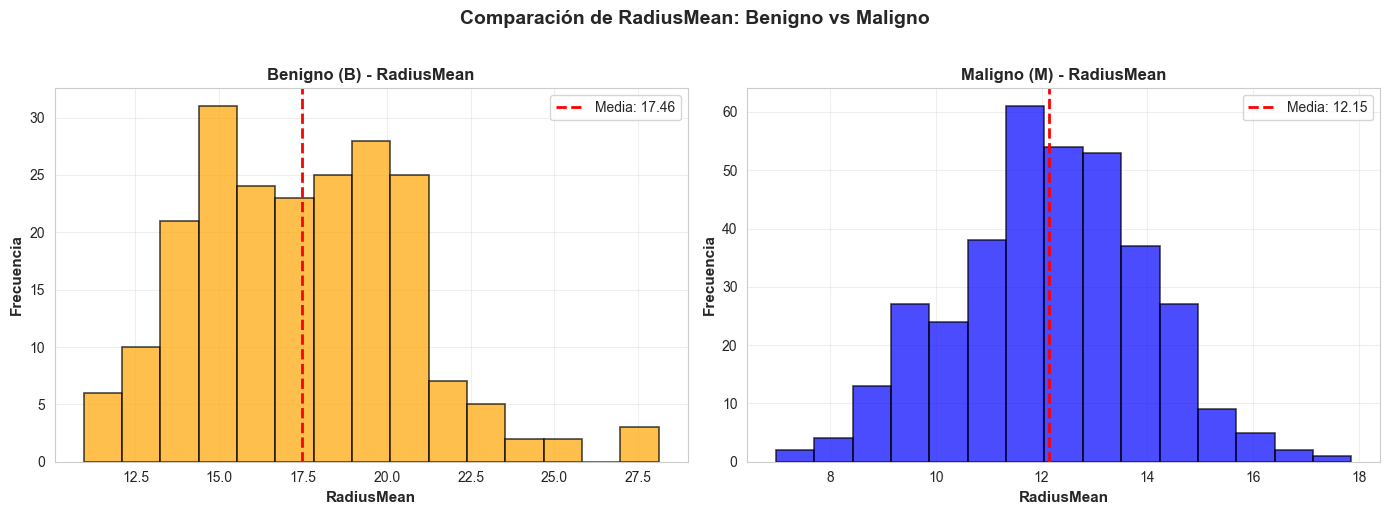

In [107]:
radius_cols = [col for col in X.columns if 'radius' in col.lower()]
print(f"Columnas que contienen 'radius': {radius_cols}")
print()

# Si X_normalized no tiene RadiusMean, usaremos X directamente
# X tiene todas las características originales antes de normalizar
if 'RadiusMean' not in X_normalized.columns and 'RadiusMean' in X.columns:
    print("✓ Usando X para el histograma (tiene todas las características originales)")
    df_para_histograma = X
    radius_mean_col = 'RadiusMean'
elif 'RadiusMean' in X_normalized.columns:
    print("✓ Usando X_normalized para el histograma")
    df_para_histograma = X_normalized
    radius_mean_col = 'RadiusMean'
elif radius_cols:
    print(f"✓ Usando X con columna alternativa: {radius_cols[0]}")
    df_para_histograma = X
    radius_mean_col = radius_cols[0]
else:
    print("✗ ERROR: No se encontró ninguna columna 'RadiusMean' o similar en los DataFrames")
    print("Columnas disponibles:", X.columns.tolist())
    raise KeyError("No se encontró la columna RadiusMean en X")

print()
print("=" * 80)
print(f"HISTOGRAMA DE {radius_mean_col} SEPARADO POR DIAGNÓSTICO")
print("=" * 80)
print()

# Separar datos por diagnóstico
radiusmean_benignos = df_para_histograma[df_para_histograma['DiagnosisNumeric'] == 0][radius_mean_col]
radiusmean_malignos = df_para_histograma[df_para_histograma['DiagnosisNumeric'] == 1][radius_mean_col]

print(f"Casos Benignos (B): {len(radiusmean_benignos)}")
print(f"Casos Malignos (M): {len(radiusmean_malignos)}")
print()

# Estadísticos por grupo
print("ESTADÍSTICOS DE RadiusMean POR DIAGNÓSTICO:")
print("-" * 80)
print(f"Benignos (B):")
print(f"  Media:     {radiusmean_benignos.mean():.4f}")
print(f"  Mediana:   {radiusmean_benignos.median():.4f}")
print(f"  Desv Std:  {radiusmean_benignos.std():.4f}")
print(f"  Min-Max:   [{radiusmean_benignos.min():.4f}, {radiusmean_benignos.max():.4f}]")
print()
print(f"Malignos (M):")
print(f"  Media:     {radiusmean_malignos.mean():.4f}")
print(f"  Mediana:   {radiusmean_malignos.median():.4f}")
print(f"  Desv Std:  {radiusmean_malignos.std():.4f}")
print(f"  Min-Max:   [{radiusmean_malignos.min():.4f}, {radiusmean_malignos.max():.4f}]")
print()

# Crear el histograma superpuesto
plt.figure(figsize=(12, 6))

# Histograma para Benignos (B) - Naranja
plt.hist(radiusmean_benignos, bins=15, alpha=0.6, label='Benigno (B)', 
         color='orange', edgecolor='black', linewidth=1.2)

# Histograma para Malignos (M) - Azul
plt.hist(radiusmean_malignos, bins=15, alpha=0.6, label='Maligno (M)', 
         color='blue', edgecolor='black', linewidth=1.2)

# Títulos y etiquetas
plt.title('Distribución de RadiusMean por Diagnóstico', fontsize=14, fontweight='bold')
plt.xlabel('RadiusMean', fontsize=12, fontweight='bold')
plt.ylabel('Frecuencia', fontsize=12, fontweight='bold')
plt.legend(fontsize=11, loc='upper right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


print()

# Crear histogramas separados (lado a lado) para mejor comparación
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Subplot 1: Benignos
axes[0].hist(radiusmean_benignos, bins=15, alpha=0.7, color='orange', edgecolor='black', linewidth=1.2)
axes[0].set_title('Benigno (B) - RadiusMean', fontsize=12, fontweight='bold')
axes[0].set_xlabel('RadiusMean', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Frecuencia', fontsize=11, fontweight='bold')
axes[0].grid(True, alpha=0.3)
axes[0].axvline(radiusmean_benignos.mean(), color='red', linestyle='--', linewidth=2, label=f'Media: {radiusmean_benignos.mean():.2f}')
axes[0].legend()

# Subplot 2: Malignos
axes[1].hist(radiusmean_malignos, bins=15, alpha=0.7, color='blue', edgecolor='black', linewidth=1.2)
axes[1].set_title('Maligno (M) - RadiusMean', fontsize=12, fontweight='bold')
axes[1].set_xlabel('RadiusMean', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Frecuencia', fontsize=11, fontweight='bold')
axes[1].grid(True, alpha=0.3)
axes[1].axvline(radiusmean_malignos.mean(), color='red', linestyle='--', linewidth=2, label=f'Media: {radiusmean_malignos.mean():.2f}')
axes[1].legend()

fig.suptitle('Comparación de RadiusMean: Benigno vs Maligno', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()



------------------------------------------------------------------------------------------------------------------------
Sigamos con gráficso de violin para multiples caracter´siticas tales como: RadiusMean, TextureMean, PerimeterMean, AreaMean, SmoothnessMean. CompactnessMean, ConcavityMean, ConcavePointsMean, Symmetry3, FractalDimension3
-------------------------------------------------------------------------------------------------------------------------

GRÁFICOS DE VIOLÍN PARA MÚLTIPLES CARACTERÍSTICAS
Características solicitadas: ['MeanRadius', 'MeanTexture', 'MeanPerimeter', 'MeanArea', 'MeanSmoothness', 'MeanCompactness', 'MeanConcavity', 'MeanConcavePoints', 'Symmetry3', 'FractalDimension3']
Columnas utilizadas: {'MeanRadius': 'MeanRadius', 'MeanTexture': 'MeanTexture', 'MeanPerimeter': 'MeanPerimeter', 'MeanArea': 'MeanArea', 'MeanSmoothness': 'MeanSmoothness', 'MeanCompactness': 'MeanCompactness', 'MeanConcavity': 'MeanConcavity', 'MeanConcavePoints': 'MeanConcavePoints', 'Symmetry3': 'SymmetryError', 'FractalDimension3': 'FractalDimensionError'}

Primeras filas de los datos reestructurados para el violin plot:
   Diagnosis     Feature     Value
0          B  MeanRadius  1.096100
1          B  MeanRadius  1.828212
2          B  MeanRadius  1.578499
3          B  MeanRadius -0.768233
4          B  MeanRadius  1.748758
5          B  MeanRadius -0.475956
6          B  MeanRadius  1.169878
7          B  MeanRadius -0.118413
8       

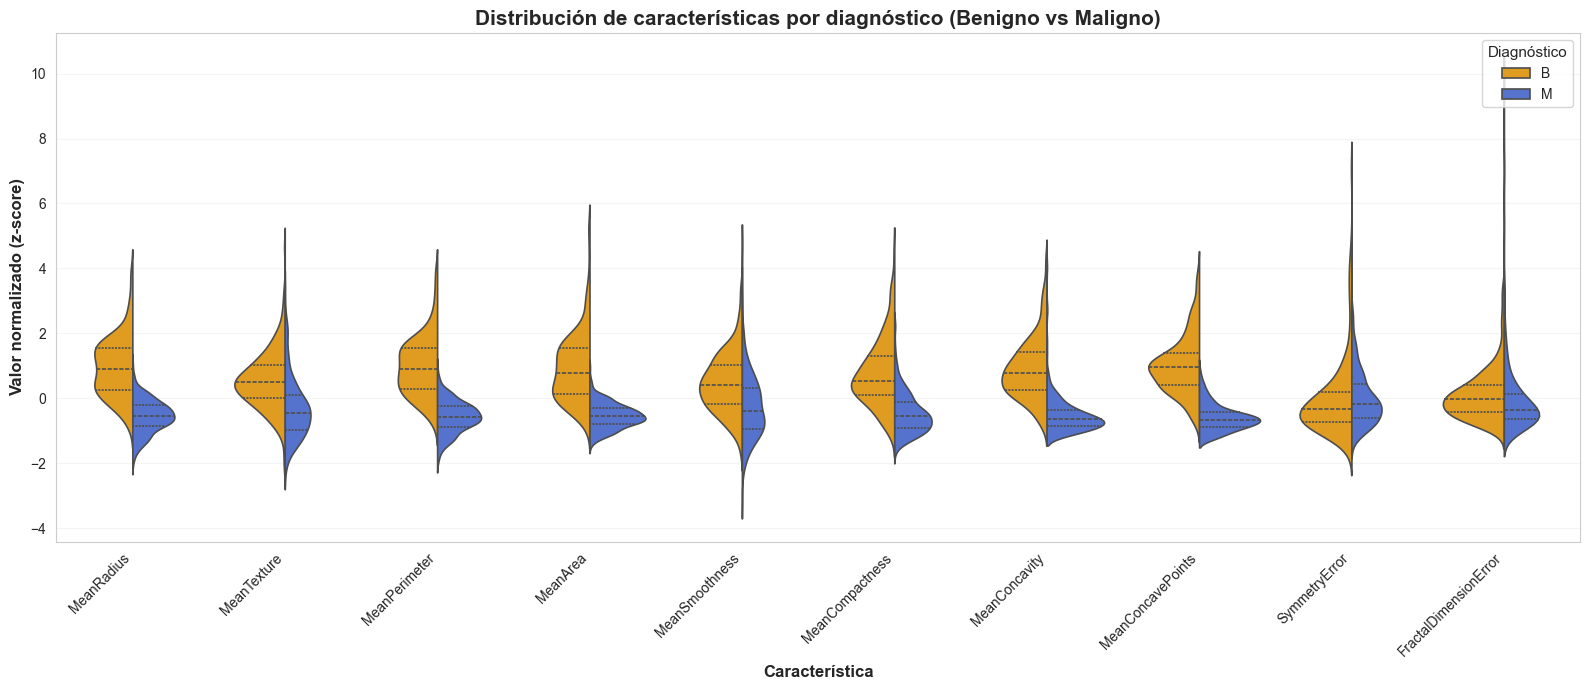

✓ Violin plot generado correctamente
RESUMEN ESTADÍSTICO DE CADA CARACTERÍSTICA POR DIAGNÓSTICO

MeanRadius (columna usada: MeanRadius)
------------------------------------------------------------
  Benignos (B) -> media: 17.4628, mediana: 17.3250, std: 3.2040
  Malignos (M) -> media: 12.1465, mediana: 12.2000, std: 1.7805
  Diferencia absoluta de medias: 5.3163

MeanTexture (columna usada: MeanTexture)
------------------------------------------------------------
  Benignos (B) -> media: 21.6049, mediana: 21.4600, std: 3.7795
  Malignos (M) -> media: 17.9148, mediana: 17.3900, std: 3.9951
  Diferencia absoluta de medias: 3.6901

MeanPerimeter (columna usada: MeanPerimeter)
------------------------------------------------------------
  Benignos (B) -> media: 115.3654, mediana: 114.2000, std: 21.8547
  Malignos (M) -> media: 78.0754, mediana: 78.1800, std: 11.8074
  Diferencia absoluta de medias: 37.2900

MeanArea (columna usada: MeanArea)
------------------------------------------------

In [114]:
# Violin plot de características solicitadas (usando datos normalizados)
import re
import seaborn as sns
import matplotlib.pyplot as plt

features_solicitadas = [
    'MeanRadius',
    'MeanTexture',
    'MeanPerimeter',
    'MeanArea',
    'MeanSmoothness',
    'MeanCompactness',
    'MeanConcavity',
    'MeanConcavePoints',
    'Symmetry3',
    'FractalDimension3'
]

print("=" * 80)
print("GRÁFICOS DE VIOLÍN PARA MÚLTIPLES CARACTERÍSTICAS")
print("=" * 80)

features_encontradas = []
features_no_encontradas = []
feature_mapping = {}

for feature in features_solicitadas:
    if feature in X_normalized.columns:
        features_encontradas.append(feature)
        feature_mapping[feature] = feature
    else:
        # Remover sufijos numéricos como "3" y buscar columnas con el mismo prefijo
        base = re.sub(r"\d+$", "", feature)
        candidatos = [col for col in X_normalized.columns if col.lower().startswith(base.lower())]
        if candidatos:
            elegido = candidatos[0]
            features_encontradas.append(elegido)
            feature_mapping[feature] = elegido
        else:
            features_no_encontradas.append(feature)

print(f"Características solicitadas: {features_solicitadas}")
print(f"Columnas utilizadas: {feature_mapping}")
if features_no_encontradas:
    print(f"Advertencia: No se encontraron columnas para {features_no_encontradas}")
print()

if not features_encontradas:
    raise ValueError("No se encontraron columnas para generar el gráfico de violín.")

# Preparamos DataFrame para el violin plot usando los datos normalizados (comparables entre sí)
df_violin = X_normalized[features_encontradas + ['DiagnosisNumeric']].copy()
diagnosis_map_reverse = {0: 'B', 1: 'M'}
df_violin['Diagnosis'] = df_violin['DiagnosisNumeric'].map(diagnosis_map_reverse)

data_violin = pd.melt(
    df_violin,
    id_vars=['Diagnosis'],
    value_vars=features_encontradas,
    var_name='Feature',
    value_name='Value'
)

print("Primeras filas de los datos reestructurados para el violin plot:")
print(data_violin.head(12))
print(f"Shape final para graficar: {data_violin.shape}")

plt.figure(figsize=(16, 7))
ax = sns.violinplot(
    data=data_violin,
    x='Feature',
    y='Value',
    hue='Diagnosis',
    split=True,
    inner='quart',
    linewidth=1.2,
    palette={'B': 'orange', 'M': 'royalblue'}
)
plt.title('Distribución de características por diagnóstico (Benigno vs Maligno)', fontsize=15, fontweight='bold')
plt.xlabel('Característica', fontsize=12, fontweight='bold')
plt.ylabel('Valor normalizado (z-score)', fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.grid(True, axis='y', alpha=0.2)
plt.legend(title='Diagnóstico', title_fontsize=11, fontsize=10, loc='upper right')
plt.tight_layout()
plt.show()

print("✓ Violin plot generado correctamente")

# Resumen estadístico por diagnóstico para cada característica seleccionada
print("=" * 80)
print("RESUMEN ESTADÍSTICO DE CADA CARACTERÍSTICA POR DIAGNÓSTICO")
print("=" * 80)
for original, col_real in feature_mapping.items():
    if col_real not in X.columns:
        base_stat_df = X_normalized
    else:
        base_stat_df = X  # si existe en X usamos los valores originales para estadísticos interpretables
    print(f"\n{original} (columna usada: {col_real})")
    print("-" * 60)
    benignos = base_stat_df.loc[X['DiagnosisNumeric'] == 0, col_real]
    malignos = base_stat_df.loc[X['DiagnosisNumeric'] == 1, col_real]
    print(f"  Benignos (B) -> media: {benignos.mean():.4f}, mediana: {benignos.median():.4f}, std: {benignos.std():.4f}")
    print(f"  Malignos (M) -> media: {malignos.mean():.4f}, mediana: {malignos.median():.4f}, std: {malignos.std():.4f}")
    print(f"  Diferencia absoluta de medias: {abs(benignos.mean() - malignos.mean()):.4f}")

El análisis de la distribución de los datos revela una clara diferenciación en las características físicas según el tipo de diagnóstico. Las variables relacionadas con la geometría y el tamaño (como el radio medio, el perímetro y el área) presentan una separación marcada entre los tumores benignos y malignos, situando a los casos benignos en rangos de valores normalizados consistentemente más altos que los malignos en esta representación.

Este mismo patrón de distinción se observa en los indicadores de irregularidad del contorno, específicamente en la concavidad y los puntos cóncavos, donde las densidades de ambos grupos apenas se solapan. Por el contrario, las variables asociadas a errores de medición o ruido, como el error de simetría y el error de dimensión fractal, muestran distribuciones casi idénticas para ambos tipos de tumores, lo que indica que estos valores no varían significativamente entre un diagnóstico y otro. Finalmente, la presencia de colas alargadas en variables como el área y el error de simetría evidencia la existencia de valores atípicos extremos dentro de la muestra analizada.

---------------------------------------------------------------------------------------------------------------------------
Eliminaremos los valores atípicos de la columna MeanRadius, para la identifiacción usaremos boxplot y el rango intercuartil para definir utliners
---------------------------------------------------------------------------------------------------------------------------

DETECCIÓN DE OUTLIERS EN MeanRadius MEDIANTE IQR


<Figure size 1400x600 with 0 Axes>

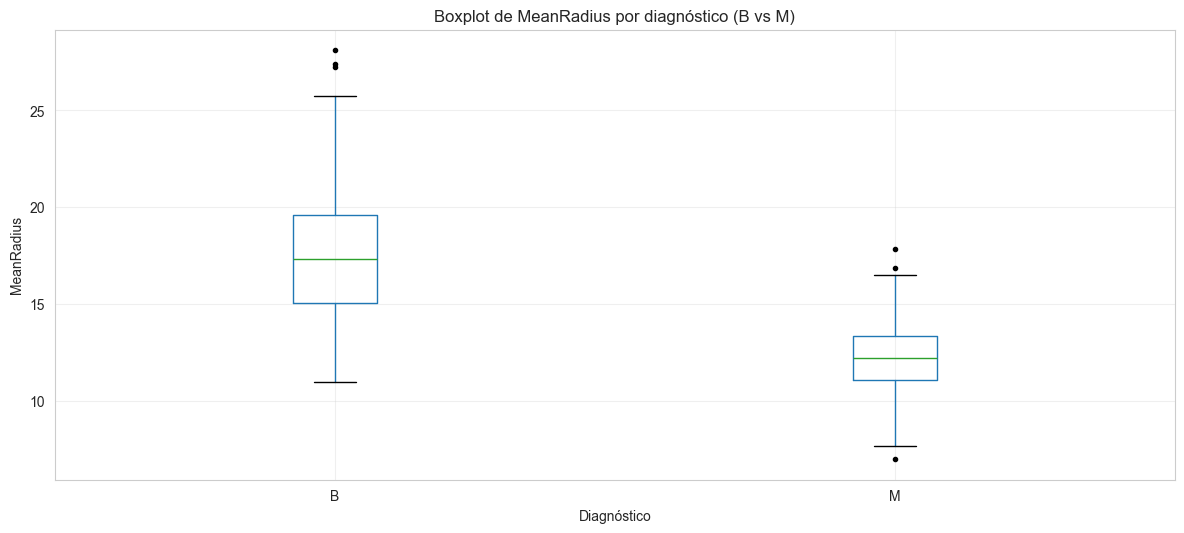

Q1 = 11.700, Q3 = 15.780, IQR = 4.080
Límite inferior = 5.580, Límite superior = 21.900
Total de observaciones: 569
Outliers detectados: 14 (2.46%)
Observaciones restantes después de eliminar outliers: 555
✓ Se eliminaron los outliers de MeanRadius usando el criterio IQR
Observaciones que cumplirían criterio |z| < 3: 564 (referencia)


In [115]:
# Boxplot e identificación de outliers en MeanRadius
import matplotlib.pyplot as plt
import numpy as np

print("=" * 80)
print("DETECCIÓN DE OUTLIERS EN MeanRadius MEDIANTE IQR")
print("=" * 80)

# Preparar DataFrame auxiliar con etiqueta B/M para el boxplot
boxplot_df = X[['MeanRadius', 'DiagnosisNumeric']].copy()
boxplot_df['Diagnosis'] = boxplot_df['DiagnosisNumeric'].map({0: 'B', 1: 'M'})

plt.figure(figsize=(14, 6))
boxplot_df.boxplot(column='MeanRadius', by='Diagnosis', sym='k.', figsize=(14, 6))
plt.title('Boxplot de MeanRadius por diagnóstico (B vs M)')
plt.suptitle('')
plt.xlabel('Diagnóstico')
plt.ylabel('MeanRadius')
plt.grid(alpha=0.3)
plt.show()

# Cálculo de límites usando IQR
Q1 = X['MeanRadius'].quantile(0.25)
Q3 = X['MeanRadius'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Q1 = {Q1:.3f}, Q3 = {Q3:.3f}, IQR = {IQR:.3f}")
print(f"Límite inferior = {lower_bound:.3f}, Límite superior = {upper_bound:.3f}")

# Identificar outliers
mask_inliers = (X['MeanRadius'] >= lower_bound) & (X['MeanRadius'] <= upper_bound)
outliers_detected = ~mask_inliers
print(f"Total de observaciones: {len(X)}")
print(f"Outliers detectados: {outliers_detected.sum()} ({outliers_detected.sum() / len(X) * 100:.2f}%)")

# Crear DataFrames sin outliers para uso posterior
X_no_outliers = X.loc[mask_inliers].copy()
X_normalized_no_outliers = X_normalized.loc[mask_inliers].copy()
X_grouped_no_outliers = X_grouped.loc[mask_inliers].copy()

print(f"Observaciones restantes después de eliminar outliers: {len(X_no_outliers)}")
print("✓ Se eliminaron los outliers de MeanRadius usando el criterio IQR")

# (Opcional) Alternativa con z-score si se requiere en el futuro
from scipy import stats
z_scores = np.abs(stats.zscore(X['MeanRadius']))
mask_zscore = z_scores < 3
print(f"Observaciones que cumplirían criterio |z| < 3: {mask_zscore.sum()} (referencia)")

--------------------------------------------------------------------------------------------------------------------
Para entender cómo se relacionan las características agrupadas entre sí, calcularemos la matriz de correlación usando `corr()` y la visualizaremos con `seaborn.heatmap()`. Usaremos la versión sin outliers.
--------------------------------------------------------------------------------------------------------------------

Usando X_grouped_no_outliers para calcular la matriz de correlación
Primeras filas de la matriz de correlación:
              Radius   Texture  Perimeter      Area  Smoothness  Compactness  \
Radius      1.000000  0.243193   0.958802  0.949938    0.134549     0.351161   
Texture     0.243193  1.000000   0.262233  0.129760    0.375748     0.212279   
Perimeter   0.958802  0.262233   1.000000  0.918494    0.122384     0.433312   
Area        0.949938  0.129760   0.918494  1.000000    0.006729     0.288576   
Smoothness  0.134549  0.375748   0.122384  0.006729    1.000000     0.317093   

            Concavity  ConcavePoints  Symmetry  FractalDimension  
Radius       0.317469       0.549251  0.228339          0.255405  
Texture      0.176949       0.231348  0.403614          0.268895  
Perimeter    0.359103       0.609353  0.264398          0.281395  
Area         0.259956       0.478482  0.096513          0.147701  
Smoothness   0.245474       0.335321  0.392508          0.419299  


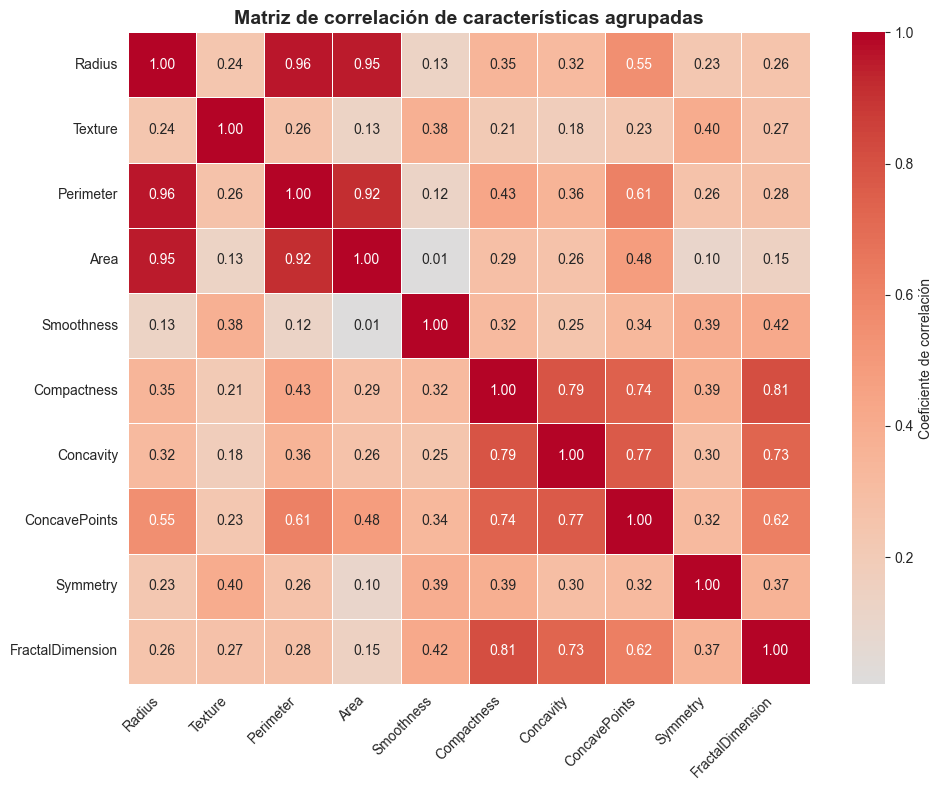

Entre mayor sea el valor absoluto del coeficiente de correlación, más fuerte es la relación lineal entre las características.


In [ ]:
# Matriz de correlación y heatmap
import seaborn as sns
import matplotlib.pyplot as plt

# Elegir el DataFrame disponible para correlaciones
if 'X_grouped_no_outliers' in globals():
    df_corr_source = 'X_grouped_no_outliers'
    df_corr_base = X_grouped_no_outliers.copy()
else:
    df_corr_source = 'X_grouped'
    df_corr_base = X_grouped.copy()

print(f"Usando {df_corr_source} para calcular la matriz de correlación")

# Excluir la columna objetivo antes de correlacionar características
feature_cols = [col for col in df_corr_base.columns if col != 'DiagnosisNumeric']
corr_matrix = df_corr_base[feature_cols].corr()

print("Primeras filas de la matriz de correlación:")
print(corr_matrix.head())

plt.figure(figsize=(10, 8))
heatmap = sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    cbar_kws={'label': 'Coeficiente de correlación'}
)
plt.title('Matriz de correlación de características agrupadas', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

print("Entre mayor sea el valor absoluto del coeficiente de correlación, más fuerte es la relación lineal entre las características.")

---------------------------------------------------------------------------------------------------------------------------
Otros gráficos para representar la información: 
* Scatter plot con tendencia: por ejemplo RadiusMean vs PerimeterMean con Diagnosis como color y líneas de tendencia. Evidencia cómo crece el perímetro con el radio en cada clase.
* Mapa de densidad: mostrar regiones donde se concentran casos benignos vs malignos usando combinaciones como ConcavityMean vs ConcavePointsMean.
* Distribuciones acumuladas: comparar la probabilidad acumulada de medidas como MeanRadius o MeanArea para ambos diagnósticos, mostrando diferencias en percentiles.
---------------------------------------------------------------------------------------------------------------------------